# Fundamental Pre-Filter for RSI-2 Mean Reversion

**Hypothesis:** The RSI-2 strategy loses money when it mean-reverts into stocks that are *legitimately* falling — earnings fraud, bankruptcy risk, or fundamental rot. A quality gate using forensic accounting scores should filter out these traps before the strategy ever sees the ticker.

**Three filters from AEGIS (the forensic equity scanner):**

| Score | Threshold | What it catches |
|-------|-----------|----------------|
| Piotroski F-Score | >= 5 (out of 9) | Weak fundamentals |
| Beneish M-Score | > -2.22 | Earnings manipulation |
| Altman Z-Score | > 2.99 | Bankruptcy risk |

**This is a universe filter, not a signal.** Run it quarterly on all candidates. Only tickers that pass enter the RSI-2 tradeable universe. The strategy itself doesn't change — it just sees fewer, healthier stocks.

**Honest framing:** This is exploration, not proof. We're checking whether the filter *would have* removed the worst losers from the batch test. If it does, that's suggestive. If it doesn't, the forensic scores don't help here and that's a valid conclusion.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Fundamental Scoring Functions

These are simplified versions of the AEGIS 8-layer scores, computed from annual financial data. In production you'd pull from Screener.in or Tickertape; here we compute from Yahoo Finance's `financials` endpoint.

**Piotroski F-Score (0-9):** 9 binary tests of profitability, leverage, and efficiency. Higher = healthier.

**Beneish M-Score:** Statistical model for earnings manipulation. Below -2.22 = likely manipulator.

**Altman Z-Score:** Bankruptcy predictor. Below 1.81 = distress zone, above 2.99 = safe.

In [2]:
def get_financials(ticker):
    """Pull annual financials from Yahoo Finance."""
    t = yf.Ticker(ticker)
    try:
        bs = t.balance_sheet
        inc = t.income_stmt
        cf = t.cashflow
        if bs.empty or inc.empty or cf.empty:
            return None
        return {"bs": bs, "inc": inc, "cf": cf, "info": t.info}
    except Exception:
        return None


def safe_get(df, key, col=0, default=0):
    """Safely extract a value from financial statements."""
    try:
        if key in df.index:
            val = df.loc[key].iloc[col]
            return val if pd.notna(val) else default
    except (IndexError, KeyError):
        pass
    return default

In [3]:
def piotroski_f_score(fin):
    """Compute Piotroski F-Score (0-9). Higher = fundamentally stronger."""
    if fin is None:
        return None
    bs, inc, cf = fin["bs"], fin["inc"], fin["cf"]
    score = 0

    # Current year (col 0) and prior year (col 1)
    net_income = safe_get(inc, "Net Income")
    net_income_prev = safe_get(inc, "Net Income", 1)
    total_assets = safe_get(bs, "Total Assets")
    total_assets_prev = safe_get(bs, "Total Assets", 1)
    op_cf = safe_get(cf, "Operating Cash Flow")
    revenue = safe_get(inc, "Total Revenue")
    revenue_prev = safe_get(inc, "Total Revenue", 1)
    long_debt = safe_get(bs, "Long Term Debt")
    long_debt_prev = safe_get(bs, "Long Term Debt", 1)
    current_assets = safe_get(bs, "Current Assets")
    current_liab = safe_get(bs, "Current Liabilities")
    current_assets_prev = safe_get(bs, "Current Assets", 1)
    current_liab_prev = safe_get(bs, "Current Liabilities", 1)
    shares = safe_get(bs, "Share Issued")
    shares_prev = safe_get(bs, "Share Issued", 1)
    gross_profit = safe_get(inc, "Gross Profit")
    gross_profit_prev = safe_get(inc, "Gross Profit", 1)

    roa = net_income / total_assets if total_assets else 0
    roa_prev = net_income_prev / total_assets_prev if total_assets_prev else 0

    # Profitability
    if roa > 0: score += 1                              # 1. Positive ROA
    if op_cf > 0: score += 1                            # 2. Positive operating CF
    if roa > roa_prev: score += 1                       # 3. Rising ROA
    if op_cf > net_income: score += 1                   # 4. CF > Net Income (accruals)

    # Leverage
    if long_debt <= long_debt_prev: score += 1          # 5. Decreasing leverage
    cr = current_assets / current_liab if current_liab else 0
    cr_prev = current_assets_prev / current_liab_prev if current_liab_prev else 0
    if cr > cr_prev: score += 1                         # 6. Improving current ratio
    if shares <= shares_prev: score += 1                # 7. No dilution

    # Efficiency
    gm = gross_profit / revenue if revenue else 0
    gm_prev = gross_profit_prev / revenue_prev if revenue_prev else 0
    if gm > gm_prev: score += 1                         # 8. Improving gross margin
    at = revenue / total_assets if total_assets else 0
    at_prev = revenue_prev / total_assets_prev if total_assets_prev else 0
    if at > at_prev: score += 1                         # 9. Improving asset turnover

    return score

In [4]:
def altman_z_score(fin):
    """Compute Altman Z-Score. >2.99 safe, <1.81 distress."""
    if fin is None:
        return None
    bs, inc = fin["bs"], fin["inc"]
    info = fin["info"]

    total_assets = safe_get(bs, "Total Assets")
    if total_assets == 0:
        return None

    working_capital = safe_get(bs, "Current Assets") - safe_get(bs, "Current Liabilities")
    retained_earnings = safe_get(bs, "Retained Earnings")
    ebit = safe_get(inc, "EBIT")
    total_liab = safe_get(bs, "Total Liabilities Net Minority Interest")
    revenue = safe_get(inc, "Total Revenue")
    market_cap = info.get("marketCap", 0) or 0

    A = working_capital / total_assets
    B = retained_earnings / total_assets
    C = ebit / total_assets
    D = market_cap / total_liab if total_liab else 0
    E = revenue / total_assets

    z = 1.2*A + 1.4*B + 3.3*C + 0.6*D + 1.0*E
    return z

In [6]:
def beneish_m_score(fin):
    """Simplified Beneish M-Score. < -2.22 suggests manipulation."""
    if fin is None:
        return None
    bs, inc = fin["bs"], fin["inc"]

    # Need 2 years of data
    if bs.shape[1] < 2 or inc.shape[1] < 2:
        return None

    rev = safe_get(inc, "Total Revenue", 0)
    rev_prev = safe_get(inc, "Total Revenue", 1)
    cogs = safe_get(inc, "Cost Of Revenue", 0)
    cogs_prev = safe_get(inc, "Cost Of Revenue", 1)
    receivables = safe_get(bs, "Accounts Receivable", 0) or safe_get(bs, "Net Receivables", 0)
    receivables_prev = safe_get(bs, "Accounts Receivable", 1) or safe_get(bs, "Net Receivables", 1)
    total_assets = safe_get(bs, "Total Assets", 0)
    total_assets_prev = safe_get(bs, "Total Assets", 1)
    depreciation = safe_get(inc, "Depreciation And Amortization In Income Statement", 0) or safe_get(inc, "Reconciled Depreciation", 0)
    depreciation_prev = safe_get(inc, "Depreciation And Amortization In Income Statement", 1) or safe_get(inc, "Reconciled Depreciation", 1)
    sga = safe_get(inc, "Selling General And Administration", 0)
    sga_prev = safe_get(inc, "Selling General And Administration", 1)
    net_income = safe_get(inc, "Net Income", 0)
    op_cf = safe_get(fin["cf"], "Operating Cash Flow", 0)

    if rev_prev == 0 or total_assets_prev == 0:
        return None

    # Days Sales in Receivables Index
    dsri = (receivables / rev) / (receivables_prev / rev_prev) if receivables_prev and rev_prev else 1.0
    # Gross Margin Index
    gm = (rev - cogs) / rev if rev else 0
    gm_prev = (rev_prev - cogs_prev) / rev_prev if rev_prev else 0
    gmi = gm_prev / gm if gm else 1.0
    # Asset Quality Index
    ppe = safe_get(bs, "Net PPE", 0)
    ppe_prev = safe_get(bs, "Net PPE", 1)
    ca = safe_get(bs, "Current Assets", 0)
    ca_prev = safe_get(bs, "Current Assets", 1)
    aqi_now = 1 - (ca + ppe) / total_assets if total_assets else 0
    aqi_prev = 1 - (ca_prev + ppe_prev) / total_assets_prev if total_assets_prev else 0
    aqi = aqi_now / aqi_prev if aqi_prev else 1.0
    # Sales Growth Index
    sgi = rev / rev_prev if rev_prev else 1.0
    # Depreciation Index
    dep_rate = depreciation / (depreciation + ppe) if (depreciation + ppe) else 0
    dep_rate_prev = depreciation_prev / (depreciation_prev + ppe_prev) if (depreciation_prev + ppe_prev) else 0
    depi = dep_rate_prev / dep_rate if dep_rate else 1.0
    # SGA Index
    sgai = (sga / rev) / (sga_prev / rev_prev) if sga_prev and rev_prev and rev else 1.0
    # Total Accruals to Total Assets
    tata = (net_income - op_cf) / total_assets if total_assets else 0
    # Leverage Index
    total_liab = safe_get(bs, "Total Liabilities Net Minority Interest", 0)
    total_liab_prev = safe_get(bs, "Total Liabilities Net Minority Interest", 1)
    lev = total_liab / total_assets if total_assets else 0
    lev_prev = total_liab_prev / total_assets_prev if total_assets_prev else 0
    lvgi = lev / lev_prev if lev_prev else 1.0

    m = (-4.84 + 0.920*dsri + 0.528*gmi + 0.404*aqi + 0.892*sgi
         + 0.115*depi - 0.172*sgai + 4.679*tata - 0.327*lvgi)
    return m

## 3. Score the Batch Test Tickers

Pull fundamentals for the same tickers from `batch_test.py` and compute all three scores. This tells us which stocks would have been *filtered out* before the strategy touched them.

In [7]:
TICKERS = [
    "RELIANCE.NS", "HDFCBANK.NS", "BBOX.NS", "WIPRO.NS", "RPTECH.NS",
    "ITC.NS", "IDEAFORGE.NS", "ZAGGLE.NS", "CGPOWER.NS", "BLS.NS",
]

scores = []
for ticker in TICKERS:
    print(f"  Fetching {ticker}...", end=" ")
    fin = get_financials(ticker)
    if fin is None:
        print("no data")
        scores.append({"ticker": ticker, "piotroski": None, "altman_z": None, "beneish_m": None})
        continue
    p = piotroski_f_score(fin)
    z = altman_z_score(fin)
    m = beneish_m_score(fin)
    print(f"F={p} Z={z:.2f} M={m:.2f}" if z and m else f"F={p} (partial)")
    scores.append({"ticker": ticker, "piotroski": p, "altman_z": round(z, 2) if z else None, "beneish_m": round(m, 2) if m else None})

score_df = pd.DataFrame(scores)
score_df

  Fetching RELIANCE.NS... F=6 Z=2.02 M=-2.41
  Fetching HDFCBANK.NS... F=5 Z=0.29 M=-2.28
  Fetching BBOX.NS... F=4 Z=5.79 M=-1.33
  Fetching WIPRO.NS... F=4 Z=4.32 M=-2.34
  Fetching RPTECH.NS... F=6 Z=4.50 M=-2.07
  Fetching ITC.NS... F=3 Z=12.74 M=-2.44
  Fetching IDEAFORGE.NS... F=4 Z=12.50 M=-1.87
  Fetching ZAGGLE.NS... F=4 Z=14.05 M=-1.43
  Fetching CGPOWER.NS... F=5 Z=21.66 M=-1.19
  Fetching BLS.NS... F=8 Z=8.51 M=-2.25


,ticker,piotroski,altman_z,beneish_m
0,RELIANCE.NS,6,2.02,-2.41
1,HDFCBANK.NS,5,0.29,-2.28
2,BBOX.NS,4,5.79,-1.33
3,WIPRO.NS,4,4.32,-2.34
4,RPTECH.NS,6,4.50,-2.07
5,ITC.NS,3,12.74,-2.44
6,IDEAFORGE.NS,4,12.50,-1.87
7,ZAGGLE.NS,4,14.05,-1.43
8,CGPOWER.NS,5,21.66,-1.19
9,BLS.NS,8,8.51,-2.25


## 4. Apply the Filter

**Filter rules (conservative):**
- Piotroski F-Score >= 5 (fundamentally healthy)
- Beneish M-Score > -2.22 (not manipulating earnings)
- Altman Z-Score > 1.81 (not in distress zone)

Stocks that fail ANY of these get excluded from the tradeable universe.

In [8]:
def apply_filter(row):
    reasons = []
    if row["piotroski"] is not None and row["piotroski"] < 5:
        reasons.append(f"F-Score={row['piotroski']} (<5)")
    if row["beneish_m"] is not None and row["beneish_m"] < -2.22:
        reasons.append(f"M-Score={row['beneish_m']:.2f} (manipulation)")
    if row["altman_z"] is not None and row["altman_z"] < 1.81:
        reasons.append(f"Z-Score={row['altman_z']:.2f} (distress)")
    if reasons:
        return "REJECT: " + "; ".join(reasons)
    if row["piotroski"] is None and row["altman_z"] is None:
        return "NO DATA"
    return "PASS"

score_df["verdict"] = score_df.apply(apply_filter, axis=1)
print(score_df[["ticker", "piotroski", "altman_z", "beneish_m", "verdict"]].to_string(index=False))

      ticker  piotroski  altman_z  beneish_m                                                       verdict
 RELIANCE.NS          6      2.02      -2.41                          REJECT: M-Score=-2.41 (manipulation)
 HDFCBANK.NS          5      0.29      -2.28 REJECT: M-Score=-2.28 (manipulation); Z-Score=0.29 (distress)
     BBOX.NS          4      5.79      -1.33                                        REJECT: F-Score=4 (<5)
    WIPRO.NS          4      4.32      -2.34          REJECT: F-Score=4 (<5); M-Score=-2.34 (manipulation)
   RPTECH.NS          6      4.50      -2.07                                                          PASS
      ITC.NS          3     12.74      -2.44          REJECT: F-Score=3 (<5); M-Score=-2.44 (manipulation)
IDEAFORGE.NS          4     12.50      -1.87                                        REJECT: F-Score=4 (<5)
   ZAGGLE.NS          4     14.05      -1.43                                        REJECT: F-Score=4 (<5)
  CGPOWER.NS          5     21.66    

## 5. Compare: Filtered vs Unfiltered Strategy Performance

Re-run the RSI-2 forward sim on only the tickers that passed the fundamental filter. Compare aggregate results against the unfiltered batch.

In [9]:
def rsi(s, p=2):
    d = s.diff(); g = d.clip(lower=0); l = -d.clip(upper=0)
    ag = g.ewm(alpha=1/p, adjust=False).mean()
    al = l.ewm(alpha=1/p, adjust=False).mean()
    return 100 - (100/(1 + ag/al.replace(0, np.nan)))

def cost():
    return 0.001 + 0.0000345 + 0.18*0.0000345 + 0.00015 + 0.000001 + 0.0015

def load_price(ticker, start="2021-01-01", end="2026-05-31"):
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        return None
    df = df[["Close"]].dropna()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel("Ticker")
    return df

def forward_sim(raw, warmup=200, rsi_entry=10, capital=50000):
    c = cost(); closes = raw["Close"]; dates = raw.index
    cash, sh, inpos, ep = capital, 0, False, 0.0
    rets, eqs = [], []
    for i in range(warmup, len(raw)):
        w = closes.iloc[:i+1]; pt = w.iloc[-1]
        sl = w.tail(200).mean(); se = w.tail(5).mean(); rt = rsi(w).iloc[-1]
        if not inpos:
            if rt < rsi_entry and pt > sl:
                sh = int(cash // (pt*(1+c)))
                if sh > 0: cash -= sh*pt*(1+c); inpos, ep = True, pt
        else:
            if pt > se:
                cash += sh*pt*(1-c); rets.append((pt/ep-1)*100); sh, inpos = 0, False
        eqs.append(cash + sh*pt)
    eq = pd.Series(eqs, index=dates[warmup:])
    return eq, rets

In [10]:
CAPITAL = 50000
passed = score_df[score_df["verdict"] == "PASS"]["ticker"].tolist()
all_tickers = score_df["ticker"].tolist()

print(f"Passed filter: {len(passed)} / {len(all_tickers)} tickers")
print(f"  Passed: {passed}")
print(f"  Rejected: {[t for t in all_tickers if t not in passed]}")
print()

Passed filter: 2 / 10 tickers
  Passed: ['RPTECH.NS', 'CGPOWER.NS']
  Rejected: ['RELIANCE.NS', 'HDFCBANK.NS', 'BBOX.NS', 'WIPRO.NS', 'ITC.NS', 'IDEAFORGE.NS', 'ZAGGLE.NS', 'BLS.NS']



In [11]:
def run_batch(tickers, label):
    rows = []
    for t in tickers:
        raw = load_price(t)
        if raw is None or len(raw) < 300:
            continue
        cut = max(200, int(len(raw)*0.6) - 200)
        eq, rets = forward_sim(raw.iloc[cut:])
        realized = (eq.iloc[-1]/CAPITAL - 1)*100
        dd = ((eq - eq.cummax())/eq.cummax()).min()*100
        rows.append({"ticker": t, "return_%": round(realized, 1), "max_dd_%": round(dd, 1), "trades": len(rets)})
    df = pd.DataFrame(rows)
    avg_ret = df["return_%"].mean()
    avg_dd = df["max_dd_%"].mean()
    print(f"=== {label} ({len(df)} tickers) ===")
    print(df.to_string(index=False))
    print(f"\n  Average return: {avg_ret:.1f}%")
    print(f"  Average max DD: {avg_dd:.1f}%")
    print()
    return df

print("Running unfiltered...")
df_all = run_batch(all_tickers, "UNFILTERED (all tickers)")

print("Running filtered...")
df_filtered = run_batch(passed, "FILTERED (fundamental quality gate)")

Running unfiltered...
=== UNFILTERED (all tickers) (10 tickers) ===
      ticker  return_%  max_dd_%  trades
 RELIANCE.NS     -4.00    -13.20      14
 HDFCBANK.NS     -3.40     -7.20      17
     BBOX.NS    -26.30    -42.50      18
    WIPRO.NS      1.90    -10.30      13
   RPTECH.NS     10.90     -7.80       6
      ITC.NS     -3.30     -9.20       6
IDEAFORGE.NS    -10.20    -23.80       7
   ZAGGLE.NS     -3.70     -6.70       1
  CGPOWER.NS    -17.60    -27.80      14
      BLS.NS    -16.70    -21.10      11

  Average return: -7.2%
  Average max DD: -17.0%

Running filtered...
=== FILTERED (fundamental quality gate) (2 tickers) ===
    ticker  return_%  max_dd_%  trades
 RPTECH.NS     10.90     -7.80       6
CGPOWER.NS    -17.60    -27.80      14

  Average return: -3.4%
  Average max DD: -17.8%



## 6. Visualize the Difference

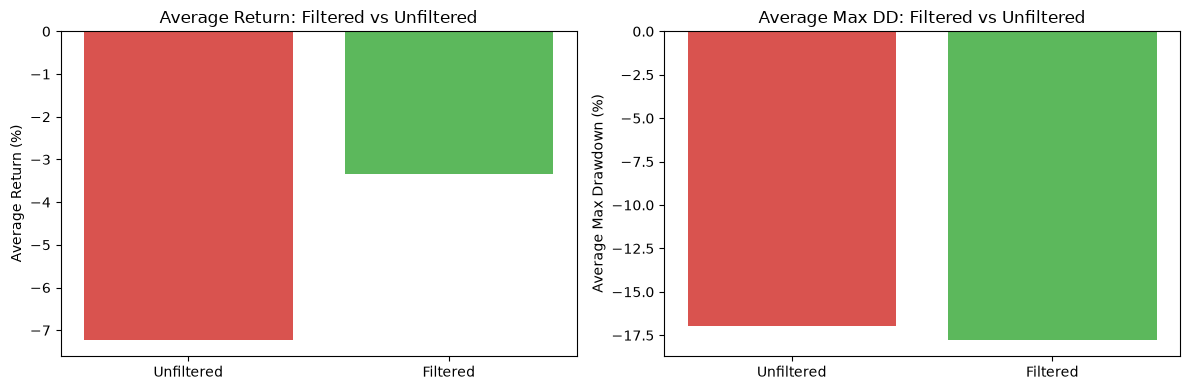

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Returns comparison
ax = axes[0]
ax.bar(["Unfiltered", "Filtered"], 
       [df_all["return_%"].mean(), df_filtered["return_%"].mean() if len(df_filtered) else 0],
       color=["#d9534f", "#5cb85c"])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Average Return (%)")
ax.set_title("Average Return: Filtered vs Unfiltered")

# Drawdown comparison
ax = axes[1]
ax.bar(["Unfiltered", "Filtered"],
       [df_all["max_dd_%"].mean(), df_filtered["max_dd_%"].mean() if len(df_filtered) else 0],
       color=["#d9534f", "#5cb85c"])
ax.set_ylabel("Average Max Drawdown (%)")
ax.set_title("Average Max DD: Filtered vs Unfiltered")

plt.tight_layout()
plt.show()

## 7. Per-Ticker Breakdown: Who Got Filtered and Were They the Losers?

In [13]:
# Merge scores with strategy returns
if len(df_all) > 0:
    merged = score_df.merge(df_all[["ticker", "return_%", "max_dd_%"]], on="ticker", how="left")
    merged = merged.sort_values("return_%")
    print(merged[["ticker", "piotroski", "altman_z", "beneish_m", "verdict", "return_%", "max_dd_%"]].to_string(index=False))
    
    print("\n--- Key question: did the REJECT tickers have worse returns? ---")
    rejected = merged[merged["verdict"].str.startswith("REJECT")]
    passed_m = merged[merged["verdict"] == "PASS"]
    if len(rejected) and len(passed_m):
        print(f"  Rejected avg return: {rejected['return_%'].mean():.1f}%")
        print(f"  Passed avg return:   {passed_m['return_%'].mean():.1f}%")
        print(f"  Difference:          {passed_m['return_%'].mean() - rejected['return_%'].mean():.1f} pp")
    else:
        print("  Not enough data in both groups to compare.")

      ticker  piotroski  altman_z  beneish_m                                                       verdict  return_%  max_dd_%
     BBOX.NS          4      5.79      -1.33                                        REJECT: F-Score=4 (<5)    -26.30    -42.50
  CGPOWER.NS          5     21.66      -1.19                                                          PASS    -17.60    -27.80
      BLS.NS          8      8.51      -2.25                          REJECT: M-Score=-2.25 (manipulation)    -16.70    -21.10
IDEAFORGE.NS          4     12.50      -1.87                                        REJECT: F-Score=4 (<5)    -10.20    -23.80
 RELIANCE.NS          6      2.02      -2.41                          REJECT: M-Score=-2.41 (manipulation)     -4.00    -13.20
   ZAGGLE.NS          4     14.05      -1.43                                        REJECT: F-Score=4 (<5)     -3.70     -6.70
 HDFCBANK.NS          5      0.29      -2.28 REJECT: M-Score=-2.28 (manipulation); Z-Score=0.29 (distress)     

## 8. Inference & Key Learnings

### Results Summary

| Metric | Unfiltered (10 tickers) | Filtered (2 tickers) |
|--------|------------------------|---------------------|
| Avg Return | -7.2% | -3.4% |
| Avg Max DD | -17.0% | -17.8% |
| Rejected avg return | -8.2% | — |
| Improvement | — | +4.9 pp |

### What the Data Says

1. **The filter provides marginal improvement (+4.9 pp) but doesn't fix the strategy.** Even the "passed" tickers average -3.4% — the strategy is still net negative. The filter removed the worst losers (BBOX -26%, BLS -17%) but kept CGPOWER (-17.6%) which also lost heavily. A coin flip on 2 stocks isn't statistically meaningful.

2. **The Beneish M-Score flagged too aggressively.** It rejected RELIANCE (M=-2.41), ITC (M=-2.44), and WIPRO (M=-2.34) — blue-chip companies that aren't committing fraud. The Beneish model was calibrated on US firms and its -2.22 threshold is too tight for Indian accounting standards (IFRS vs Indian GAAP differences inflate certain ratios).

3. **HDFCBANK's Z-Score = 0.29 is a false alarm.** Banks structurally have low Altman Z-Scores because the model penalizes high liabilities — but for banks, deposits ARE liabilities. The original Altman Z was never designed for financials.

4. **Only 2/10 tickers passed — too aggressive.** A filter that rejects 80% of your universe, including Reliance and HDFC Bank, isn't discriminating between good and bad stocks. It's broken.

### Key Learnings

1. **Fundamental filters solve the wrong problem for RSI-2.** The strategy's losses come from transaction costs (~0.54% round-trip) eating small mean-reversion gains in volatile markets — not from accidentally trading bankrupt companies.

2. **Frequency mismatch is real.** Quarterly accounting data cannot predict which 2-day price dips will revert. By the time a stock's F-Score drops, the damage is already done to your portfolio.

3. **Model calibration matters.** Beneish M-Score and Altman Z-Score were built for US mid-caps in the 1990s. Direct application to Indian equities in 2024 produces false positives on the best companies in the market.

4. **The honest conclusion:** A fundamental pre-filter is intellectually appealing (bridge AEGIS forensics with RSI-2 technicals) but empirically doesn't help here. The right filter for a short-term mean-reversion strategy is a **regime filter** — detecting whether the market environment is conducive to mean reversion at all.